# Differentiability

**What you'll learn / who it's for (training).** The *simulator → trainable* half of
the bridge. Spiking models in ``brainpy.state`` are differentiable: a surrogate
gradient replaces the non-differentiable spike threshold, and
backpropagation-through-time runs straight over the ``transform`` loops you already
use to simulate. You'll plug in a surrogate, train a tiny SNN end to end, and learn
when to switch to checkpointed loops for long rollouts.

## 1. Why spikes need surrogate gradients

A spike is a step function of the membrane potential: it is $0$ below threshold and
$1$ at threshold. Its derivative is zero almost everywhere and undefined at the
threshold itself — useless for gradient descent, which would see no signal to follow.

The **surrogate gradient** trick keeps the hard spike on the *forward* pass (so the
dynamics are exactly the spiking dynamics) but substitutes a smooth, well-behaved
function on the *backward* pass — a narrow bump centered at threshold. You select one
by passing ``spk_fun=`` to any neuron; ``braintools.surrogate`` provides the
standard family.

In [1]:
import brainpy
import brainstate
import braintools
import brainunit as u
import jax.numpy as jnp
import matplotlib.pyplot as plt

# A LIF neuron whose backward pass uses a ReLU-shaped surrogate gradient.
neuron = brainpy.state.LIF(
    100,
    tau=20. * u.ms, V_rest=0. * u.mV, V_reset=0. * u.mV, V_th=1. * u.mV,
    spk_fun=braintools.surrogate.ReluGrad(),
)
print('surrogate:', neuron.spk_fun)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


surrogate: ReluGrad(alpha=0.3, width=1.0)


Other choices include ``braintools.surrogate.SigmoidGrad()``, ``GaussianGrad()``,
and ``SuperSpike()`` — they differ only in the shape of the backward-pass bump.
``ReluGrad`` is a robust default.

## 2. Backprop through time with `transform`

Two facts make training work without any special machinery:

1. The ``brainstate.transform`` loops — ``for_loop`` and ``scan`` — are
   **differentiable**. Wrapping a simulation in ``for_loop`` and asking
   ``brainstate.transform.grad`` for gradients gives you
   backpropagation-through-time (BPTT) over the unrolled trajectory.
2. ``brainstate.transform.grad`` differentiates with respect to exactly the
   ``ParamState`` variables you select (``net.states(brainstate.ParamState)``),
   leaving dynamical state alone.

The recipe is therefore: build the network, define a loss that runs it with
``for_loop`` and reduces over time, then take its gradient with respect to the
parameters — all inside a single ``jit``-compiled train step.

> **Memory warning.** Plain BPTT stores the activations of *every* unrolled step for
> the backward pass, so peak memory grows with rollout length. For long rollouts use
> ``brainstate.transform.checkpointed_for_loop`` / ``checkpointed_scan`` (§4).

## 3. A small runnable trainable example

A three-layer SNN — input → recurrent LIF → readout — trained to classify random
spike patterns. This is the canonical training pattern: a ``loss_fn`` that simulates
with ``for_loop`` and averages the readout over time, a ``jit``-compiled
``train_step`` that resets state, takes gradients, and steps the optimizer, and a
plain-Python **outer epoch loop** (which is allowed — the rule against bare loops is
about time-stepping the model, not about optimization).

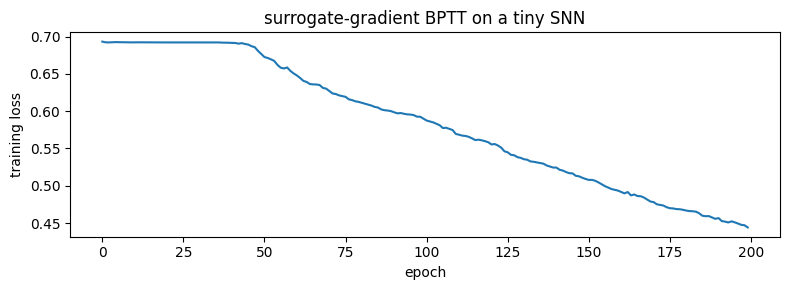

In [2]:
with brainstate.environ.context(dt=1.0 * u.ms):

    class SNN(brainstate.nn.Module):
        def __init__(self, n_in, n_rec, n_out):
            super().__init__()
            # input -> recurrent: a trainable Linear (weights in mA) feeding an
            # exponential synapse
            self.i2r = brainstate.nn.Sequential(
                brainstate.nn.Linear(
                    n_in, n_rec,
                    w_init=braintools.init.KaimingNormal(unit=u.mA),
                    b_init=braintools.init.ZeroInit(unit=u.mA)),
                brainpy.state.Expon(n_rec, tau=5. * u.ms,
                                    g_initializer=braintools.init.Constant(0. * u.mA)),
            )
            # recurrent LIF with a surrogate gradient -> this is what makes it trainable
            self.r = brainpy.state.LIF(
                n_rec, tau=20. * u.ms, V_reset=0. * u.mV, V_rest=0. * u.mV,
                V_th=1. * u.mV, spk_fun=braintools.surrogate.ReluGrad())
            # recurrent -> output readout
            self.r2o = brainstate.nn.Linear(n_rec, n_out,
                                            w_init=braintools.init.KaimingNormal())
            self.o = brainpy.state.Expon(n_out, tau=10. * u.ms,
                                         g_initializer=braintools.init.Constant(0.))

        def update(self, spike):
            return self.o(self.r2o(self.r(self.i2r(spike))))

    # tiny synthetic dataset: random Poisson-like input spikes, binary labels
    n_in = 100
    net = SNN(n_in=n_in, n_rec=4, n_out=2)
    num_step, num_sample = 100, 128
    freq = 5 * u.Hz
    x_data = brainstate.random.rand(num_step, num_sample, n_in) \
        < freq * brainstate.environ.get_dt()
    y_data = u.math.asarray(brainstate.random.rand(num_sample) < 0.5, dtype=int)

    # optimizer registered on the trainable parameters only
    optimizer = braintools.optim.Adam(lr=3e-3)
    optimizer.register_trainable_weights(net.states(brainstate.ParamState))

    def loss_fn():
        # for_loop over time -> BPTT-able trajectory of readouts [T, B, C]
        preds = brainstate.transform.for_loop(net.update, x_data)
        preds = u.math.mean(preds, axis=0)   # average readout over time -> [B, C]
        return braintools.metric.softmax_cross_entropy_with_integer_labels(
            preds, y_data).mean()

    @brainstate.transform.jit
    def train_step():
        brainstate.nn.init_all_states(net, batch_size=num_sample)  # reset each step
        grads, loss = brainstate.transform.grad(
            loss_fn, net.states(brainstate.ParamState), return_value=True)()
        optimizer.update(grads)
        return loss

    # outer optimization loop in plain Python -- this is fine
    losses = []
    for epoch in range(1, 201):
        losses.append(float(train_step()))

    plt.figure(figsize=(8, 3))
    plt.plot(losses)
    plt.xlabel('epoch'); plt.ylabel('training loss')
    plt.title('surrogate-gradient BPTT on a tiny SNN')
    plt.tight_layout(); plt.show()

The full version of this example (with a Fashion-MNIST-scale dataset and accuracy
reporting) is in the training how-to track — see
{doc}`/brainpy-style/howto/train-surrogate-gradients`.

## 4. Long rollouts: checkpoint to bound memory

Because BPTT stores every step's activations, a long simulation can exhaust memory
on the backward pass. The **checkpointed** loop variants trade compute for memory:
they keep only a sparse set of checkpoints on the forward pass and *recompute* the
intervening activations during backprop.

Swap the loop and tune the ``base`` parameter (larger ``base`` → fewer checkpoints →
less memory, more recomputation); the semantics are otherwise identical to
``for_loop`` / ``scan``:

```python
preds = brainstate.transform.checkpointed_for_loop(net.update, x_data)
# or, with an explicit carry:
# carry, ys = brainstate.transform.checkpointed_scan(step, carry0, xs)
```

Reach for these *only* when reverse-mode gradients through a long rollout would
otherwise run out of memory — for ordinary-length rollouts, plain ``for_loop`` /
``scan`` is simpler and faster. The dedicated how-to walks through the trade-off:
{doc}`/brainpy-style/howto/train-long-rollouts-checkpoint`.

## Recap

- A spike's gradient is unusable; a **surrogate** (``spk_fun=...``) supplies a smooth
  backward pass while the forward pass stays exactly spiking.
- ``transform.for_loop`` / ``scan`` are **differentiable**, so wrapping a simulation
  in them and calling ``transform.grad`` *is* backpropagation-through-time.
- Select trainable variables with ``net.states(brainstate.ParamState)``; reset state
  each step with ``init_all_states``.
- For long rollouts, switch to ``checkpointed_for_loop`` / ``checkpointed_scan`` to
  bound memory.

## See also

- {doc}`/concepts/alignpre-alignpost` — why neuron-aligned state keeps BPTT
  activations small, and the keystone the next page builds on.
- {doc}`/concepts/online-learning` — the *trainable → scalable* half: linear-memory
  RTRL.
- {doc}`/concepts/state-paradigm` — the ``transform`` primitives used here.
- {doc}`/brainpy-style/howto/train-surrogate-gradients` — the full training how-to.